In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install google-cloud-bigquery pandas

from google.cloud import bigquery
import pandas as pd

In [ ]:
from google.cloud import bigquery
from google.colab import auth

# 1. Authenticate
auth.authenticate_user()

# 2. Project ID set kar
project_id = 'valued-night-500712-v9'

# 3. Client create kar (yahan project_id dena zaroori hai)
client = bigquery.Client(project=project_id)

# 4. QUERY LIKHTE WAQT FULL PATH DO (Project.Dataset.Table)
query = """
    SELECT *
    FROM `valued-night-500712-v9.AQI_Data_raw.air_quality_records`
    LIMIT 100
"""

df = client.query(query).to_dataframe()
print(df.head())

         date    state      area  number_of_monitoring_stations  \
0  2025-04-29  Tripura  Agartala                              1   
1  2025-04-28  Tripura  Agartala                              1   
2  2025-04-27  Tripura  Agartala                              1   
3  2025-04-26  Tripura  Agartala                              1   
4  2025-04-25  Tripura  Agartala                              1   

  prominent_pollutants  aqi_value air_quality_status  \
0                   O3        154           Moderate   
1                   O3        231               Poor   
2                   O3        333          Very Poor   
3                 PM10         24               Good   
4                 PM10         28               Good   

                                                unit  note  
0  number_of_monitoring_stations in Absolute Numb...  None  
1  number_of_monitoring_stations in Absolute Numb...  None  
2  number_of_monitoring_stations in Absolute Numb...  None  
3  number_of_mon

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   date                           100 non-null    dbdate
 1   state                          100 non-null    object
 2   area                           100 non-null    object
 3   number_of_monitoring_stations  100 non-null    Int64 
 4   prominent_pollutants           100 non-null    object
 5   aqi_value                      100 non-null    Int64 
 6   air_quality_status             100 non-null    object
 7   unit                           100 non-null    object
 8   note                           0 non-null      object
dtypes: Int64(2), dbdate(1), object(6)
memory usage: 7.4+ KB


,0
date,0
state,0
area,0
number_of_monitoring_stations,0
prominent_pollutants,0
aqi_value,0
air_quality_status,0
unit,0
note,100


In [ ]:
# 1. Basic Stats & Structure
print("--- DataFrame Info ---")
df.info()

# 2. Missing Values (Data Quality)
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Duplicate Records
print(f"\n--- Duplicate Rows: {df.duplicated().sum()} ---")

# 4. Range and Unique Values
print("\n--- Unique Categories in Status ---")
print(df['air_quality_status'].value_counts())

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   date                           100 non-null    dbdate
 1   state                          100 non-null    object
 2   area                           100 non-null    object
 3   number_of_monitoring_stations  100 non-null    Int64 
 4   prominent_pollutants           100 non-null    object
 5   aqi_value                      100 non-null    Int64 
 6   air_quality_status             100 non-null    object
 7   unit                           100 non-null    object
 8   note                           0 non-null      object
dtypes: Int64(2), dbdate(1), object(6)
memory usage: 7.4+ KB

--- Missing Values ---
date                               0
state                              0
area                               0
number_of_monitoring_stations

In [ ]:
import pandas as pd

# 1. Transform: Dropping and Mapping
df_clean = df.drop(columns=['note'])

status_map = {'Good': 1, 'Moderate': 2, 'Poor': 3, 'Very Poor': 4}
df_clean['air_quality_status_num'] = df_clean['air_quality_status'].map(status_map)

# 2. Standardize: Column names clean karna
df_clean.columns = [c.lower().replace(' ', '_') for c in df_clean.columns]

print("Transformation Complete.")
print(df_clean.head())

Transformation Complete.
         date    state      area  number_of_monitoring_stations  \
0  2025-04-29  Tripura  Agartala                              1   
1  2025-04-28  Tripura  Agartala                              1   
2  2025-04-27  Tripura  Agartala                              1   
3  2025-04-26  Tripura  Agartala                              1   
4  2025-04-25  Tripura  Agartala                              1   

  prominent_pollutants  aqi_value air_quality_status  \
0                   O3        154           Moderate   
1                   O3        231               Poor   
2                   O3        333          Very Poor   
3                 PM10         24               Good   
4                 PM10         28               Good   

                                                unit  air_quality_status_num  
0  number_of_monitoring_stations in Absolute Numb...                       2  
1  number_of_monitoring_stations in Absolute Numb...                       3 

In [ ]:
import os

# Check karo ki folder exist karta hai ya nahi
output_dir = 'data/processed'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Folder '{output_dir}' created successfully!")
else:
    print(f"Folder '{output_dir}' already exists.")

Folder 'data/processed' created successfully!


In [ ]:
import sqlite3
import os

# Absolute path set karo
db_path = os.path.join(os.getcwd(), 'data', 'processed', 'aqi_data.db')

try:
    conn = sqlite3.connect(db_path)
    df_clean.to_sql('air_quality', conn, if_exists='replace', index=False)
    conn.close()
    print(f"Success! Data loaded into: {db_path}")
except Exception as e:
    print(f"Error: {e}")

Success! Data loaded into: /content/data/processed/aqi_data.db


In [ ]:
import sqlite3
import pandas as pd

# Database se data read karke dekho
conn = sqlite3.connect('/content/data/processed/aqi_data.db')
query = "SELECT * FROM air_quality LIMIT 5"
df_check = pd.read_sql_query(query, conn)
conn.close()

print("Database check successful! here is data:")
print(df_check)

Database check successful! here is data:
         date    state      area  number_of_monitoring_stations  \
0  2025-04-29  Tripura  Agartala                              1   
1  2025-04-28  Tripura  Agartala                              1   
2  2025-04-27  Tripura  Agartala                              1   
3  2025-04-26  Tripura  Agartala                              1   
4  2025-04-25  Tripura  Agartala                              1   

  prominent_pollutants  aqi_value air_quality_status  \
0                   O3        154           Moderate   
1                   O3        231               Poor   
2                   O3        333          Very Poor   
3                 PM10         24               Good   
4                 PM10         28               Good   

                                                unit  air_quality_status_num  
0  number_of_monitoring_stations in Absolute Numb...                       2  
1  number_of_monitoring_stations in Absolute Numb...         

In [ ]:
import logging
import sys

# Logger setup karo
logger = logging.getLogger()
logger.setLevel(logging.INFO)

# File handler (File mein likhega)
file_handler = logging.FileHandler('project_logs.log', mode='w')
file_handler.setFormatter(logging.Formatter('%(asctime)s - %(message)s'))
logger.addHandler(file_handler)

# Stream handler (Console mein dikhayega)
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setFormatter(logging.Formatter('%(message)s'))
logger.addHandler(stream_handler)

# Test karo
logger.info("Pipeline test: Agar ye dikh raha hai, toh logging setup ho gaya!")

INFO:root:Pipeline test: Agar ye dikh raha hai, toh logging setup ho gaya!


Pipeline test: Agar ye dikh raha hai, toh logging setup ho gaya!


In [ ]:
import sqlite3

# Connection setup
conn = sqlite3.connect('/content/data/processed/aqi_data.db')
cursor = conn.cursor()

# 1. Create Locations Table
cursor.execute('''
CREATE TABLE IF NOT EXISTS locations (
    location_id INTEGER PRIMARY KEY AUTOINCREMENT,
    city_name TEXT NOT NULL UNIQUE,
    state TEXT
)
''')

# 2. Create AQI Readings Table
cursor.execute('''
CREATE TABLE IF NOT EXISTS aqi_readings (
    reading_id INTEGER PRIMARY KEY AUTOINCREMENT,
    location_id INTEGER,
    date TEXT,
    aqi_value INTEGER,
    status_num INTEGER,
    FOREIGN KEY (location_id) REFERENCES locations(location_id)
)
''')

conn.commit()
print("Tables 'locations' and 'aqi_readings' created successfully!")
conn.close()

Tables 'locations' and 'aqi_readings' created successfully!


In [ ]:
print(df_old.columns)

Index(['date', 'state', 'area', 'number_of_monitoring_stations',
       'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit',
       'air_quality_status_num'],
      dtype='object')


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('/content/data/processed/aqi_data.db')
cursor = conn.cursor()

# 1. Purana data load karo
df_old = pd.read_sql_query("SELECT * FROM air_quality", conn)

# 2. Locations table mein unique 'area' aur 'state' insert karo
locations = df_old[['area', 'state']].drop_duplicates()
for _, row in locations.iterrows():
    cursor.execute("INSERT OR IGNORE INTO locations (city_name, state) VALUES (?, ?)", (row['area'], row['state']))

# 3. Reading table ke liye data migrate karo
for _, row in df_old.iterrows():
    # 'area' ko use karke location_id fetch karo
    cursor.execute("SELECT location_id FROM locations WHERE city_name = ?", (row['area'],))
    result = cursor.fetchone()

    if result:
        loc_id = result[0]
        cursor.execute('''
            INSERT INTO aqi_readings (location_id, date, aqi_value, status_num)
            VALUES (?, ?, ?, ?)
        ''', (loc_id, row['date'], row['aqi_value'], row['air_quality_status_num']))

conn.commit()
print("Migration Complete! Data ab normalized tables mein hai.")
conn.close()

Migration Complete! Data ab normalized tables mein hai.


In [ ]:
import os
print(os.listdir())  # Ye dikhayega ki tumhari notebook ke folder mein kya-kya hai

['.config', 'data', 'drive', 'project_logs.log', 'sample_data']


In [ ]:
import os
print(os.listdir('data'))

['processed']


In [ ]:
import os
print(os.listdir('data/processed'))

['aqi_data.db']


In [ ]:
import sqlite3
import pandas as pd

# 1. Connect to DB
conn = sqlite3.connect('data/processed/aqi_data.db')

# 2. 'aqi_readings' table se data load karo
df = pd.read_sql("SELECT * FROM aqi_readings", conn)
conn.close()

# 3. Data Validation Function
def validate_aqi_data(df):
    errors = []

    # Check for missing values (Nulls)
    if df.isnull().values.any():
        errors.append(f"Missing values found in: {df.columns[df.isnull().any()].tolist()}")

    # Check if 'AQI' column exists (Assuming standard column name is 'AQI')
    if 'AQI' in df.columns:
        # Range check: AQI cannot be negative
        if (df['AQI'] < 0).any():
            errors.append("Negative AQI values detected!")
    else:
        errors.append("Column 'AQI' not found in table.")

    return errors

# 4. Execute
validation_errors = validate_aqi_data(df)

if not validation_errors:
    print("✅ Data validation passed! Data is clean.")
else:
    print("❌ Data validation failed!")
    for error in validation_errors:
        print(f" - {error}")

❌ Data validation failed!
 - Column 'AQI' not found in table.


In [ ]:
import sqlite3
import pandas as pd

# Connect to DB
conn = sqlite3.connect('data/processed/aqi_data.db')

# Columns check karne ke liye query
df_info = pd.read_sql("SELECT * FROM aqi_readings LIMIT 5", conn)
print("Columns in aqi_readings table:", df_info.columns.tolist())
print("\nFirst 5 rows:\n", df_info.head())

conn.close()

Columns in aqi_readings table: ['reading_id', 'location_id', 'date', 'aqi_value', 'status_num']

First 5 rows:
    reading_id  location_id        date  aqi_value  status_num
0           1            1  2025-04-29        154           2
1           2            1  2025-04-28        231           3
2           3            1  2025-04-27        333           4
3           4            1  2025-04-26         24           1
4           5            1  2025-04-25         28           1


In [ ]:
import sqlite3
import pandas as pd

# 1. Database Connect karo
conn = sqlite3.connect('data/processed/aqi_data.db')

# 2. Data load karo
df = pd.read_sql("SELECT * FROM aqi_readings", conn)
conn.close()

# 3. Updated Validation Function
def validate_aqi_data(df):
    errors = []

    # Check 1: Missing Values
    if df.isnull().values.any():
        errors.append(f"Missing values found in: {df.columns[df.isnull().any()].tolist()}")

    # Check 2: Range Check (aqi_value logical check)
    # Typically AQI 0-500 ke beech hota hai.
    if ((df['aqi_value'] < 0) | (df['aqi_value'] > 1000)).any():
        errors.append("Out of range AQI values detected (should be 0-1000)!")

    # Check 3: Unique IDs check
    if not df['reading_id'].is_unique:
        errors.append("Duplicate reading_ids found!")

    return errors

# 4. Run Validation
validation_errors = validate_aqi_data(df)

if not validation_errors:
    print("✅ Data validation passed! Phase 10 Successfully Complete.")
else:
    print("❌ Data validation failed!")
    for error in validation_errors:
        print(f" - {error}")

✅ Data validation passed! Phase 10 Successfully Complete.


In [ ]:
import sqlite3

# 1. Connect to DB
conn = sqlite3.connect('data/processed/aqi_data.db')
cursor = conn.cursor()

# 2. SQL Cleaning Operations
try:
    # A. TRIM (Whitespace hatana)
    cursor.execute("UPDATE aqi_readings SET date = TRIM(date)")

    # B. CAST (Data type consistency - e.g., ensure aqi_value is integer)
    cursor.execute("UPDATE aqi_readings SET aqi_value = CAST(aqi_value AS INTEGER)")

    # C. COALESCE (NULL values ko 0 se replace karna)
    cursor.execute("UPDATE aqi_readings SET aqi_value = COALESCE(aqi_value, 0)")

    # D. CASE (AQI categorization - Status labeling)
    # 1=Good, 2=Moderate, 3=Poor, 4=Hazardous
    cursor.execute("""
        UPDATE aqi_readings
        SET status_num = CASE
            WHEN aqi_value <= 50 THEN 1
            WHEN aqi_value <= 100 THEN 2
            WHEN aqi_value <= 200 THEN 3
            ELSE 4
        END
    """)

    # E. DELETE (Invalid data hatao - e.g., negative values)
    cursor.execute("DELETE FROM aqi_readings WHERE aqi_value < 0")

    # F. DISTINCT (Duplicate records hatane ke liye check)
    cursor.execute("DELETE FROM aqi_readings WHERE rowid NOT IN (SELECT MIN(rowid) FROM aqi_readings GROUP BY location_id, date)")

    conn.commit()
    print("✅ SQL Data Cleaning Phase completed successfully!")

except Exception as e:
    print(f"❌ Error during cleaning: {e}")
    conn.rollback()

finally:
    conn.close()

✅ SQL Data Cleaning Phase completed successfully!


In [ ]:
from google.cloud import bigquery
import pandas as pd

# BigQuery client setup
client = bigquery.Client(project='valued-night-500712-v9')

# Query to fetch enriched data
query = """
SELECT * FROM `valued-night-500712-v9.AQI_Data_raw.enriched_aqi_data`
"""

# Fetch into Pandas DataFrame
df = client.query(query).to_dataframe()

# Quick check
print(df.head())
print(df.describe())

         date    state      area  station_count station_category  is_weekend
0  2024-12-10  Tripura  Agartala              1              Low           0
1  2023-06-21  Tripura  Agartala              1              Low           0
2  2024-06-29  Tripura  Agartala              1              Low           1
3  2024-08-25  Tripura  Agartala              1              Low           1
4  2022-06-25  Tripura  Agartala              1              Low           1
       station_count  is_weekend
count       235785.0    235785.0
mean        1.870653    0.286367
std         3.071575    0.452064
min              1.0         0.0
25%              1.0         0.0
50%              1.0         0.0
75%              1.0         1.0
max             40.0         1.0


In [ ]:
import pandas as pd
import numpy as np

# Assuming 'df' is already loaded from Phase 14
# 1. Descriptive stats
stats = df.describe()

# 2. Correlation between station_count and is_weekend
correlation = df[['station_count', 'is_weekend']].corr()

# 3. Aggregation: Average stations by Category
category_analysis = df.groupby('station_category')['station_count'].agg(['mean', 'count', 'std'])

print("--- Statistical Summary ---")
print(stats)
print("\n--- Category Performance ---")
print(category_analysis)

--- Statistical Summary ---
       station_count  is_weekend
count       235785.0    235785.0
mean        1.870653    0.286367
std         3.071575    0.452064
min              1.0         0.0
25%              1.0         0.0
50%              1.0         0.0
75%              1.0         1.0
max             40.0         1.0

--- Category Performance ---
                       mean   count       std
station_category                             
High              31.678154    1625  5.937517
Low                1.319884  221074  0.756656
Medium             7.473865   13086  3.015646


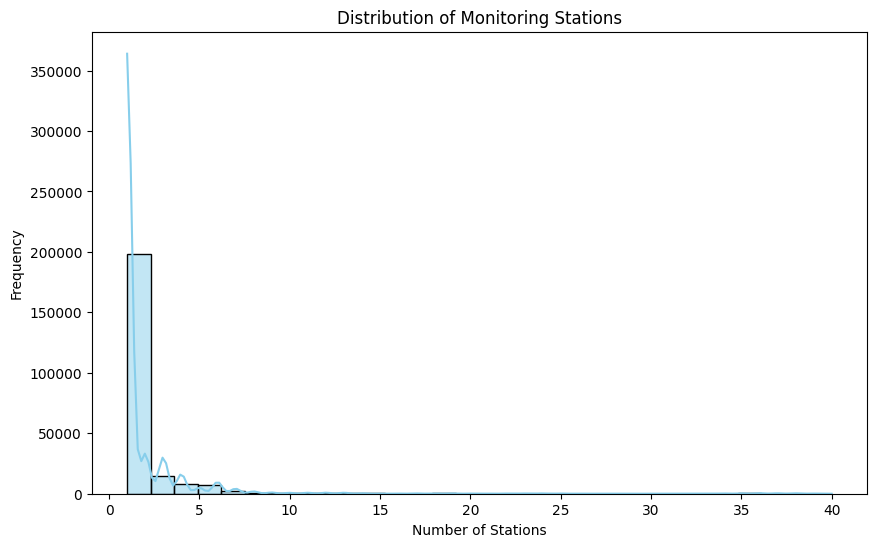

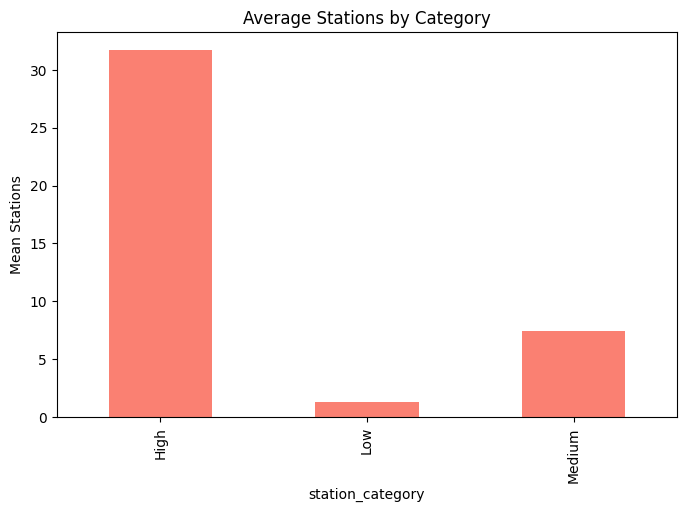

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual 1: Station Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['station_count'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Monitoring Stations')
plt.xlabel('Number of Stations')
plt.ylabel('Frequency')
plt.show()

# Visual 2: Category wise average
plt.figure(figsize=(8, 5))
category_analysis['mean'].plot(kind='bar', color='salmon')
plt.title('Average Stations by Category')
plt.ylabel('Mean Stations')
plt.show()

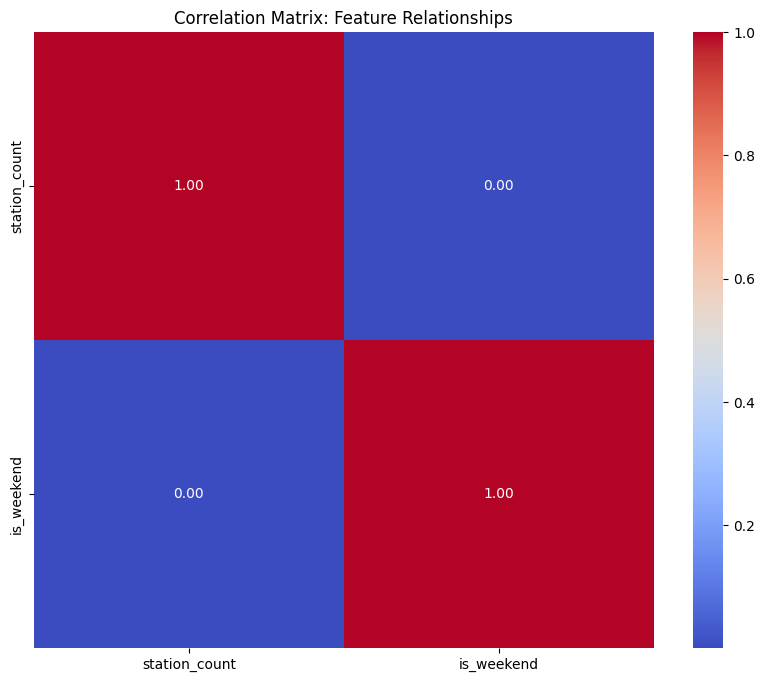

In [ ]:
# Sabse pehle numeric columns filter karo
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation matrix calculation
corr_matrix = numeric_df.corr()

# Heatmap visualize karo
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Feature Relationships")
plt.show()

In [ ]:
from scipy import stats

# Groups define karo
high_group = df[df['station_category'] == 'High']['station_count']
low_group = df[df['station_category'] == 'Low']['station_count']

# Independent T-Test
t_stat, p_value = stats.ttest_ind(high_group, low_group)

print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("Result Significant hai: Dono categories mein bada farak hai!")
else:
    print("Result Significant nahi hai.")

T-Statistic: 1342.0556016952899
P-Value: 0.0
Result Significant hai: Dono categories mein bada farak hai!


In [ ]:
import numpy as np
import scipy.stats as st

# Confidence interval 95% ke liye
data = df['station_count']
mean = np.mean(data)
sem = st.sem(data)
interval = st.norm.interval(0.95, loc=mean, scale=sem)

print(f"95% Confidence Interval for Station Count: {interval}")

95% Confidence Interval for Station Count: (np.float64(1.8582553642923594), np.float64(1.8830513346070619))
